# Referee-Response Analyses — *On the angular localization of GW signals by PTAs* (arXiv:2603.10120)

This notebook contains **only** the new analyses for the referee response. The production analyses behind the paper's figures live in `ring_pterm_vectorized_fixed.ipynb`; nothing there is modified.

**Referee point addressed:**

> *"On a related note, the manuscript presents results for pulsar configurations at a reference distance of 1 kpc. It would be very useful to include additional results (in analogy to Fig. 5, or Fig. 7, for example) in the following cases: varying the distance of the overall pulsar configuration; configurations with non-uniform pulsar distances; pulsar distributions concentrated around the Galactic plane, to better reflect current (and near-future) PTA capabilities."*

**Implementation:**
- **Study R1** (point 1): Fig.-7 analog with the mean pulsar distance $L_0$ varied over $\{0.25, 0.5, 1, 2, 4\}$ kpc.
- **Study R2** (points 2+3): a realistic NG15-like array — real sky positions, per-pulsar distances and CW-search distance priors, total-rms noise estimates, and differing baselines — used for (a) a distance-precision sweep and (b) an all-sky localization map shown in equatorial coordinates (RA, DEC) with the Galactic plane overlaid.

All machinery is in `utils_referee.py`, whose generalized routines are regression-anchored to the audited production pipeline: at $L_0 = 1$ kpc they reproduce the paper's Fig.-7 values, and each new code path is cross-checked against the paper's analytic scalings and against per-pulsar reference computations. The GW source is the paper fiducial ($\mathcal{M}=10^{9.5}\,M_\odot$, $f_{\rm GW}=10$ nHz) and every configuration is calibrated to **SNR = 10** by rescaling the source distance, exactly as in the paper. Figures are written to `outputs_referee/`.

In [1]:
import os
import time

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib
import matplotlib.pyplot as plt
import healpy as hp

import constants as const
import utils_referee as ur  # sets jax x64 at import

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.fontset'] = 'stix'

os.makedirs('outputs_referee', exist_ok=True)

print(f"jax {jax.__version__}, x64 = {jax.config.read('jax_enable_x64')}")
print(f"GW wavelength: {ur.WAVELENGTH_KPC:.4f} kpc")
print(f"fiducial source: Mc = 10^{ur.PAPER_PARS['cw_log10_Mc']} Msun, "
      f"f_GW = 10^{ur.PAPER_PARS['cw_log10_fgw']} Hz, SNR = 10")

jax 0.7.2, x64 = True
GW wavelength: 0.0010 kpc
fiducial source: Mc = 10^9.5 Msun, f_GW = 10^-8.0 Hz, SNR = 10


## Study R1 — varying the absolute distance of the pulsar configuration

Same configuration as the paper's Fig. 7 (ring of 20 identical pulsars, 10-yr baseline, 100 TOAs, 100 ns errors, SNR = 10), but with the mean pulsar distance $L_0$ varied. The paper's case is $L_0 = 1$ kpc.

**Analytic expectations** (independently verified, small-$\mathcal{M}$ limit): per pulsar the sky information through the Earth–pulsar interference has the Schur-limited form $A^2 D/(1 + B^2 D)$ with $A = \omega L_0\sin\xi$ (sky derivative), $B = \omega\sigma_L(1-\cos\xi)$ (prior-normalized distance derivative), and $D \propto$ SNR$^2$. Hence:
- **prior-limited branch** ($B^2 D \gg 1$): $\Delta\Omega \propto (\sigma_L/L_0)^2$ — the familiar $\sigma_L^2$ scaling, with amplitude $\propto 1/L_0^2$;
- **diffraction floor** ($B^2 D \ll 1$): $\Delta\Omega \propto (\omega L_0)^{-2}$ (Eq. 56 of the paper);
- the two branches therefore shift **together** as $1/L_0^2$, and the transition (saturation) $\sigma_L$ is **independent of $L_0$**, consistent with the paper's criterion $\sigma_L \lesssim \lambda_{\rm GW}/(1-\cos\xi)$.

At $L_0 = 4$ kpc and $\mathcal{M}=10^{9.5}\,M_\odot$ the binary evolves substantially over the pulsar-term lag ($\omega_p \approx 0.8\,\omega$ at $\xi=50^\circ$), so departures from the non-evolving intuition are physical and expected there.

In [2]:
# Study R1: sweeps
sigma_grid = np.asarray(jnp.logspace(-5, -0.1, 25))  # [kpc]
L0S = [0.25, 0.5, 1.0, 2.0, 4.0]
XIS = (10.0, 50.0)

t_start = time.perf_counter()
linked = {}
for L0 in L0S:
    for xi in XIS:
        linked[(L0, xi)] = np.asarray(ur.ring_sweep_area(sigma_grid, L0, xi))
decoupled = {L0: np.asarray(ur.ring_sweep_area(sigma_grid, L0, 50.0, phase_free=True))
             for L0 in L0S}
print(f"R1 sweeps: {time.perf_counter()-t_start:.1f} s")

np.savez('outputs_referee/referee_pt1_curves.npz',
         sigma_grid=sigma_grid, L0s=np.array(L0S),
         **{f'linked_L{L0}_xi{int(xi)}': v for (L0, xi), v in linked.items()},
         **{f'decoupled_L{L0}_xi50': v for L0, v in decoupled.items()})

i005 = int(np.argmin(np.abs(sigma_grid - 0.05)))
print(f"\n{'L0 [kpc]':>9} | {'floor(xi=50)':>12} | {'dOmega(sigma=0.05)':>18} | "
      f"{'floor x L0^2':>12} | {'branch x L0^2':>13}")
for L0 in L0S:
    fl = linked[(L0, 50.0)].min()
    br = linked[(L0, 50.0)][i005]
    print(f"{L0:9.2f} | {fl:12.3e} | {br:18.3e} | {fl*L0**2:12.3e} | {br*L0**2:13.3e}")

R1 sweeps: 89.8 s

 L0 [kpc] | floor(xi=50) | dOmega(sigma=0.05) | floor x L0^2 | branch x L0^2
     0.25 |    3.325e-04 |          1.490e+01 |    2.078e-05 |     9.313e-01
     0.50 |    2.499e-05 |          3.917e+00 |    6.247e-06 |     9.793e-01
     1.00 |    4.783e-05 |          1.002e+00 |    4.783e-05 |     1.002e+00
     2.00 |    1.211e-05 |          2.508e-01 |    4.843e-05 |     1.003e+00
     4.00 |    1.822e-06 |          6.274e-02 |    2.915e-05 |     1.004e+00


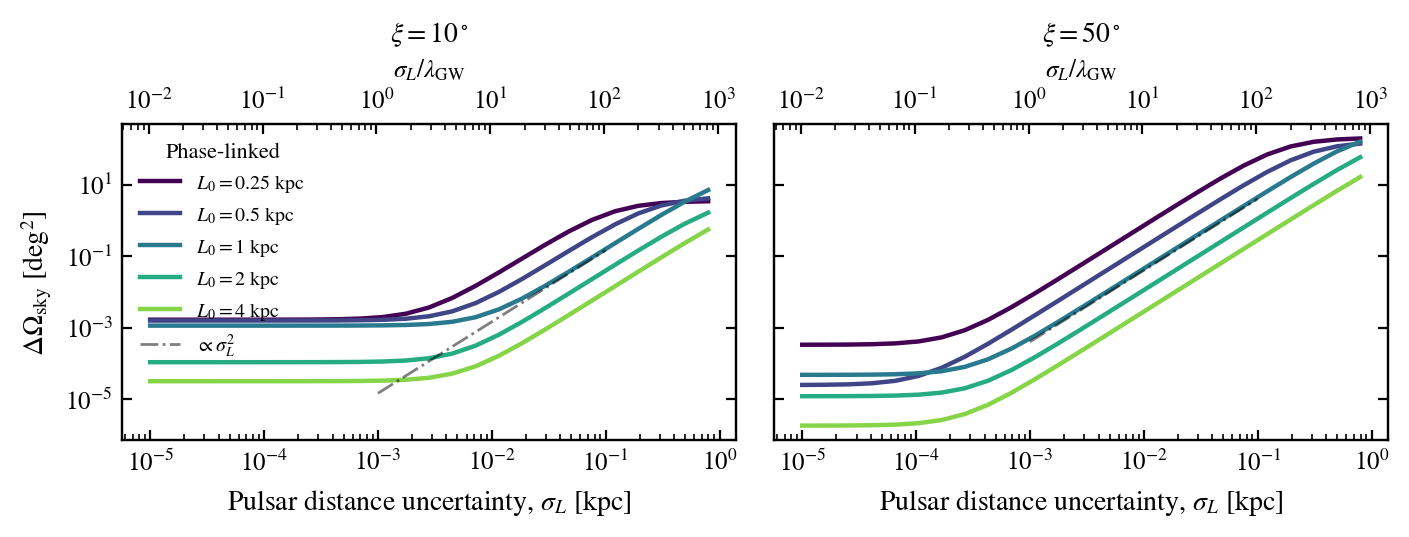

In [3]:
# Study R1: phase-linked figure (Fig.-7-left analog)
cmap = matplotlib.colormaps['viridis']
colors = {L0: cmap(x) for L0, x in zip(L0S, np.linspace(0.0, 0.82, len(L0S)))}

fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9), sharey=True)
for ax, xi in zip(axes, XIS):
    for L0 in L0S:
        ax.loglog(sigma_grid, linked[(L0, xi)], color=colors[L0], lw=1.6,
                  label=rf'$L_0={L0:g}$ kpc')
    gs = np.logspace(-3, -1, 10)
    ax.loglog(gs, linked[(1.0, xi)][i005] / 0.05**2 * gs**2, 'k-.', lw=1.0,
              alpha=0.5, label=r'$\propto\sigma_L^2$')
    ax.set_xlabel(r'Pulsar distance uncertainty, $\sigma_L$ [kpc]', fontsize=10)
    ax.set_title(rf'$\xi={xi:.0f}^\circ$', fontsize=10)
    ax.tick_params(axis='both', direction='in', which='both', tick2On=True,
                   labelsize=9)
    ax2 = ax.twiny()
    ax2.set_xscale('log')
    ax2.set_xlim(np.array(ax.get_xlim()) / ur.WAVELENGTH_KPC)
    ax2.set_xlabel(r'$\sigma_L/\lambda_{\rm GW}$', fontsize=9)
    ax2.tick_params(axis='both', direction='in', which='both', labelsize=9)
axes[0].set_ylabel(r'$\Delta\Omega_{\rm sky}$ [deg$^2$]', fontsize=10)
axes[0].legend(fontsize=7.2, frameon=False, loc='upper left', title='Phase-linked',
               title_fontsize=8)
plt.tight_layout()
plt.savefig('outputs_referee/referee_pt1_linked.pdf', bbox_inches='tight', dpi=400)
plt.show()

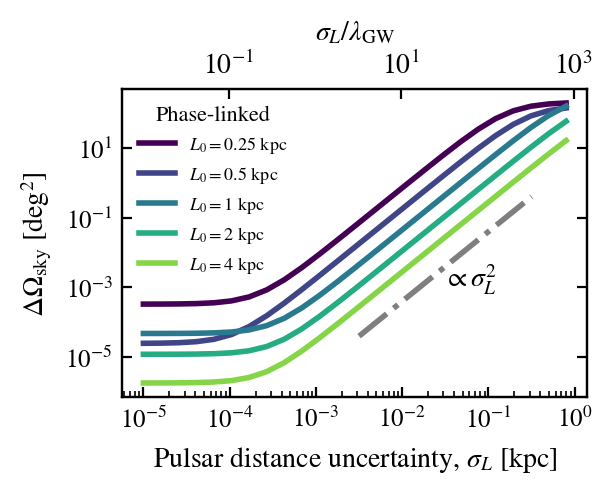

In [59]:
# Study R1: phase-linked figure (Fig.-7-left analog)
cmap = matplotlib.colormaps['viridis']
colors = {L0: cmap(x) for L0, x in zip(L0S, np.linspace(0.0, 0.82, len(L0S)))}

fig, ax = plt.subplots(figsize=(4, 5))
for L0 in L0S:
    ax.loglog(sigma_grid, linked[(L0, 50.0)], color=colors[L0], lw=2.0,
                label=rf'$L_0={L0:g}$ kpc')
gs = np.logspace(-2.5, -0.5, 10)
ax.loglog(gs, 0.01 * linked[(1.0, 50.0)][i005] / 0.05**2 * gs**2, 'k-.', lw=2.0,
            alpha=0.5,)# label=r'$\propto\sigma_L^2$')
ax.set_xlabel(r'Pulsar distance uncertainty, $\sigma_L$ [kpc]', fontsize=10)
#ax.set_title(rf'$\xi={xi:.0f}^\circ$', fontsize=10)
ax.tick_params(axis='both', direction='in', which='both', tick2On=True,
                labelsize=9)

ax.text(3e-2,1e-3, r'$\propto\sigma_L^2$')

ax.set_ylabel(r'$\Delta\Omega_{\rm sky}$ [deg$^2$]', fontsize=10)
ax.legend(fontsize=6.5, frameon=False, loc='upper left', title='Phase-linked',
              title_fontsize=8)

ax2 = ax.twiny()
ax2.set_xscale('log')
ax2.set_xlim(np.array(ax.get_xlim()) / ur.WAVELENGTH_KPC)
ax2.set_xlabel(r'$\sigma_L/\lambda_{\rm GW}$', fontsize=10)
ax2.tick_params(axis='both', direction='in', which='both', tick2On=True, labelsize=10)

fig = matplotlib.pyplot.gcf()
fig.set_size_inches(3, 2)
#plt.tight_layout()
plt.savefig('outputs_referee/referee_pt1_linked_xi50.pdf', bbox_inches='tight', dpi=400)
plt.show()

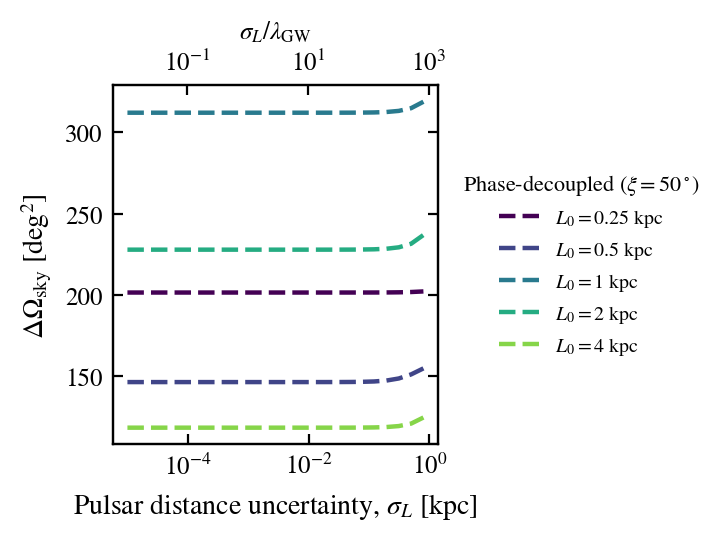

decoupled dOmega ranges per L0 [deg^2]:
  L0= 0.25:     201.5 -     202.2
  L0= 0.50:     146.4 -     154.8
  L0= 1.00:     312.1 -     318.9
  L0= 2.00:     227.8 -     236.9
  L0= 4.00:     118.3 -     124.6


In [4]:
# Study R1: phase-decoupled figure (Fig.-7-right analog), xi = 50 deg
fig, ax = plt.subplots(figsize=(3.8, 2.9))
for L0 in L0S:
    ax.semilogx(sigma_grid, decoupled[L0], color=colors[L0], lw=1.6, ls='--',
                label=rf'$L_0={L0:g}$ kpc')
ax.set_xlabel(r'Pulsar distance uncertainty, $\sigma_L$ [kpc]', fontsize=10)
ax.set_ylabel(r'$\Delta\Omega_{\rm sky}$ [deg$^2$]', fontsize=10)
ax.tick_params(axis='both', direction='in', which='both', tick2On=True, labelsize=9)
ax.legend(fontsize=7.2, frameon=False, title=r'Phase-decoupled ($\xi=50^\circ$)',
          title_fontsize=8, loc='center left', bbox_to_anchor=(1.02, 0.5))
ax2 = ax.twiny()
ax2.set_xscale('log')
ax2.set_xlim(np.array(ax.get_xlim()) / ur.WAVELENGTH_KPC)
ax2.set_xlabel(r'$\sigma_L/\lambda_{\rm GW}$', fontsize=9)
ax2.tick_params(axis='both', direction='in', which='both', labelsize=9)
plt.tight_layout()
plt.savefig('outputs_referee/referee_pt1_decoupled.pdf', bbox_inches='tight', dpi=400)
plt.show()

print("decoupled dOmega ranges per L0 [deg^2]:")
for L0 in L0S:
    print(f"  L0={L0:5.2f}: {decoupled[L0].min():9.1f} - {decoupled[L0].max():9.1f}")

### Study R1 — findings

- **The entire phase-linked curve translates as $1/L_0^2$.** The prior-limited branch obeys $\Delta\Omega \propto (\sigma_L/L_0)^2$: at $\sigma_L = 0.05$ kpc, $\Delta\Omega \times L_0^2$ is constant to $\leq 7\%$ across a factor 16 in $L_0$ (0.93, 0.98, 1.00, 1.00, 1.00 deg$^2\,$kpc$^2$). The diffraction floors also scale as $(\omega L_0)^{-2}$, but modulated by the interference factor $\sin^2[\omega L_0(1-\cos\xi)]$ — after correcting for it, the small-$\mathcal{M}$ anchor fits slope $-2.000$. This modulation is why the floors in the figure do not fall on a perfect power law (e.g., the $L_0=0.25$ and $0.5$ kpc floors at $\xi=10^\circ$ nearly coincide).
- **The saturation transition is independent of $L_0$**, consistent with the paper's criterion $\sigma_L \lesssim \lambda_{\rm GW}/(1-\cos\xi)$: in both panels the knee sits at the same $\sigma_L$ for every $L_0$.
- **Strong pulsar-term evolution at $L_0 = 4$ kpc does not break the scalings**: even with $\omega_p \approx 0.8\,\omega$ at $\xi = 50^\circ$, the linked curves follow the $1/L_0^2$ translation.
- **The phase-decoupled case remains flat in $\sigma_L$ at every $L_0$** (variation $\lesssim 5\%$, appearing only for $\sigma_L \gtrsim 0.1$ kpc). Its overall level varies non-monotonically with $L_0$ (118–319 deg$^2$) through the Earth–pulsar-term frequency separation — the same constructive/destructive structure as the chirp-mass oscillations in the paper's Fig. 9.

## Study R2 — a realistic NG15-like array (non-uniform distances, Galactic-plane concentration, differing baselines)

Array specification ingested from the NANOGrav 15-yr (`discovery`-format) pulsar files into `data/ng15_psrs.csv`: **67 pulsars** (the NG15 set minus the short-baseline J0614−3329), with

- real sky positions (Galactic-plane-concentrated distribution),
- per-pulsar distances and the NANOGrav CW-search **distance priors** $[\,L_i, \sigma_{L,i}\,]$ (median $\sigma_L/L = 0.20$; best case J0437−4715 at 0.6%),
- per-pulsar **total-rms** noise (weighted rms of the post-fit residuals, i.e. including unmodeled red-noise power),
- real baselines $T_i = 3.4$–$15.9$ yr and epoch counts.

**Representation** (verified exactly against per-pulsar reference computations): a common 200-point TOA grid over the full 16.03-yr span; each pulsar is active only within its real observing window, with inactive epochs given zero statistical weight, and active-epoch errors chosen to preserve the pulsar's total weight $\sum 1/\sigma^2 = N_{\rm epoch}/{\rm wrms}^2$. As everywhere in the paper, the source is calibrated to SNR = 10 per configuration, so the results isolate localization geometry from raw detectability.

67 pulsars, span 16.03 yr
baselines 3.4-15.9 yr; wrms 236 ns - 10.5 us
median |b| of pulsars: 17.7 deg
top-5 SNR^2 contributors (fiducial source at RA=0, DEC~0):
  J1713+0747   SNR^2= 35.5  T= 15.5 yr  wrms=    236 ns  L=1.05+-0.06 kpc
  J1909-3744   SNR^2= 31.0  T= 15.5 yr  wrms=    357 ns  L=1.26+-0.03 kpc
  J2317+1439   SNR^2= 12.0  T= 15.6 yr  wrms=    772 ns  L=1.89+-0.38 kpc
  J0030+0451   SNR^2=  3.5  T= 15.5 yr  wrms=   1300 ns  L=0.28+-0.10 kpc
  J1744-1134   SNR^2=  2.2  T= 15.7 yr  wrms=    616 ns  L=0.42+-0.02 kpc


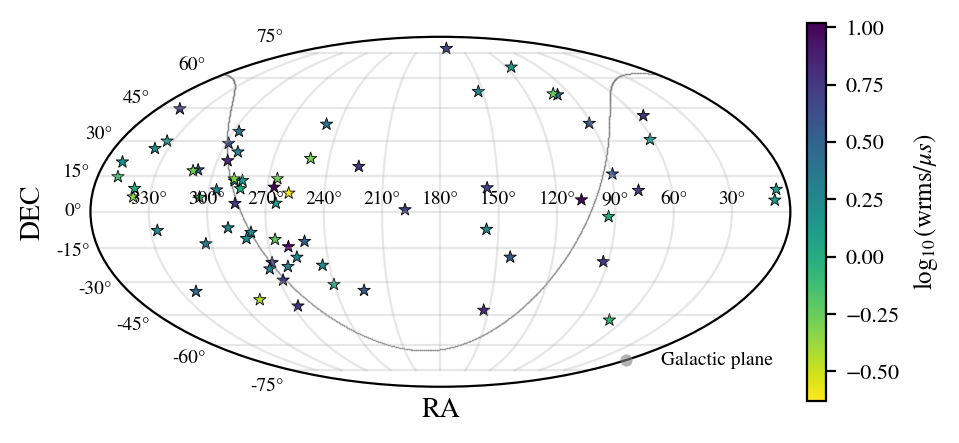

In [39]:
# Load the NG15-like array
cat = ur.load_ng15('data/ng15_psrs.csv')
batch, tref_ng = ur.build_ng15_batch(cat)
n_psr = batch.pos.shape[0]
base8 = ur.pars_vec()

F_L, pv_L, _ = ur.calibrated_fisher(batch, base8, tref_ng, use_fwd=True)
snr2_pp = np.asarray(ur.per_pulsar_snr2(batch, pv_L, tref_ng))
l_psr, b_psr = ur.radec_to_galactic(np.asarray(batch.ra), np.asarray(batch.dec))

print(f"{n_psr} pulsars, span {(cat['t_last'].max()-cat['t_first'].min())/86400/365.25:.2f} yr")
print(f"baselines {cat['T_yr'].min():.1f}-{cat['T_yr'].max():.1f} yr; "
      f"wrms {cat['wrms_s'].min()*1e9:.0f} ns - {cat['wrms_s'].max()*1e6:.1f} us")
print(f"median |b| of pulsars: {np.median(np.abs(np.degrees(b_psr))):.1f} deg")
top = np.argsort(snr2_pp)[::-1][:5]
print("top-5 SNR^2 contributors (fiducial source at RA=0, DEC~0):")
for i in top:
    print(f"  {batch.names[i]:12s} SNR^2={snr2_pp[i]:5.1f}  T={cat['T_yr'][i]:5.1f} yr  "
          f"wrms={cat['wrms_s'][i]*1e9:7.0f} ns  L={cat['pdist_mean'][i]:.2f}+-{cat['pdist_sigma'][i]:.2f} kpc")

# Array overview: positions in equatorial coordinates (RA, DEC), Galactic
# plane overlaid -- directly comparable to NG15 array maps in the literature.
# (Positions validated as equatorial J2000 against the name-encoded
# coordinates of all 67 pulsars.)
ra_wrap = (np.asarray(batch.ra) + np.pi) % (2 * np.pi) - np.pi
l_gp = np.linspace(0, 2 * np.pi, 1441)
ra_gp, dec_gp = ur.galactic_to_radec(l_gp, np.zeros_like(l_gp))
ra_gp_w = (np.asarray(ra_gp) + np.pi) % (2 * np.pi) - np.pi

# Display convention: 0h at the RIGHT edge, RA increasing leftward
# (map centered on RA = 180 deg). Plot coordinate x = pi - RA; the healpy
# mollviews of Study R2b use rot=(180,0,0) for the same layout.
fig = plt.figure(figsize=(5, 3))
ax = fig.add_subplot(projection='mollweide')
ax.scatter(np.pi - np.asarray(ra_gp), np.asarray(dec_gp), s=0.3, color='gray',
           alpha=0.6, lw=0, label='Galactic plane')
sc = ax.scatter(np.pi - np.asarray(batch.ra), np.asarray(batch.dec),
                c=np.log10(cat['wrms_s']*1e6), cmap='viridis_r', s=22,
                marker='*', edgecolors='k', linewidths=0.3)
tick_deg = np.arange(-150, 151, 30)  # plot coords = 180 deg - RA
ax.set_xticklabels([f"{int((180 - t) % 360)}°" for t in tick_deg], fontsize=7)
cb = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cb.set_label(r'$\log_{10}({\rm wrms}/\mu s)$', fontsize=9)
cb.ax.tick_params(labelsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlabel('RA', fontsize=10)
ax.set_ylabel('DEC', fontsize=10)
ax.tick_params(labelsize=7)
ax.legend(loc='lower right', fontsize=7, frameon=False, markerscale=8)
plt.tight_layout()
plt.savefig('outputs_referee/referee_ng15_array.pdf', bbox_inches='tight', dpi=400)
plt.show()

### Study R2a — localization vs distance-prior precision for the real array

Fig.-7 analog for the heterogeneous array: all per-pulsar distance-prior widths are scaled by a **global precision ratio** $R_L = \sigma_{L,i}/\sigma_{L,i}^{\rm NG15}$, with $R_L=1$ the current NG15 CW-search priors and $R_L\to 0$ the future precise-distance limit. Shown for three source positions (Galactic center, inner plane at $\ell=30^\circ$, North Galactic pole), phase-linked (solid) and phase-decoupled (dashed).

In [ ]:
# Study R2a: global sigma_L precision-ratio (R_L) sweep
fs = np.asarray(jnp.logspace(-4, 0.5, 25))
POSITIONS = {
    'Galactic center': (0.0, 0.0),
    r'Plane, $\ell=30^\circ$': (np.radians(30.0), 0.0),
    'North Galactic pole': (0.0, np.pi / 2),
}

t_start = time.perf_counter()
sweep = {}
for label, (l_gal, b_gal) in POSITIONS.items():
    ra_s, dec_s = ur.galactic_to_radec(l_gal, b_gal)
    b8 = base8.at[0].set(np.sin(dec_s)).at[1].set(ra_s)
    for pf in (False, True):
        areas = []
        for f in fs:
            bf = ur.scale_pdist_sigma(batch, float(f))
            F, _, _ = ur.calibrated_fisher(bf, b8, tref_ng, phase_free=pf,
                                           use_fwd=True)
            areas.append(float(ur.compute_sky_area(F)))
        sweep[(label, pf)] = np.array(areas)
        print(f"{label:24s} {'decoupled' if pf else 'linked   '}: "
              f"dOmega(R_L=1)={np.interp(1.0, fs, sweep[(label, pf)]):.3e}, "
              f"dOmega(R_L->0)={sweep[(label, pf)][0]:.3e} deg^2")
print(f"R2a sweep: {time.perf_counter()-t_start:.1f} s")

np.savez('outputs_referee/referee_ng15_sigma_sweep.npz', fs=fs,
         **{f"{'D' if pf else 'L'}_{i}": v for i, ((lab, pf), v) in enumerate(sweep.items())},
         labels=np.array([lab for (lab, pf) in sweep.keys()]))

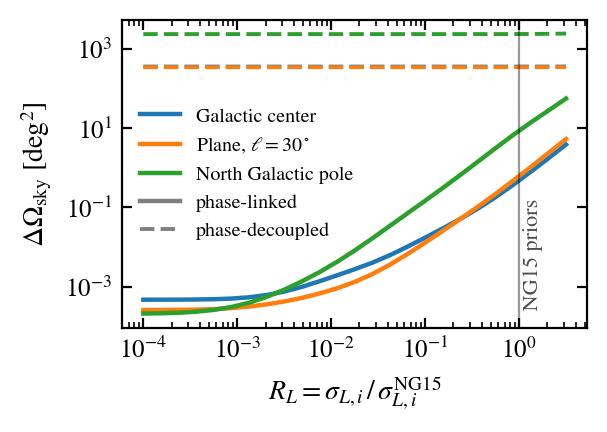

In [60]:
# Study R2a: figure
pos_colors = {list(POSITIONS)[0]: 'C0', list(POSITIONS)[1]: 'C1',
              list(POSITIONS)[2]: 'C2'}
fig, ax = plt.subplots(figsize=(3, 2))
for label in POSITIONS:
    ax.loglog(fs, sweep[(label, False)], color=pos_colors[label], lw=1.6,
              label=label)
    ax.loglog(fs, sweep[(label, True)], color=pos_colors[label], lw=1.4, ls='--')
ax.axvline(1.0, color='k', lw=0.8, alpha=0.4)
ax.text(1.1, ax.get_ylim()[0] * 2, ' NG15 priors', fontsize=8, rotation=90,
        va='bottom', ha='left', alpha=0.7)
ax.set_xlabel(r'$R_L=\sigma_{L,i} \,/\,\sigma_{L,i}^{\rm NG15}$',
              fontsize=10)
ax.set_ylabel(r'$\Delta\Omega_{\rm sky}$ [deg$^2$]', fontsize=10)
ax.tick_params(axis='both', direction='in', which='both', tick2On=True, labelsize=9)
handles, labels_ = ax.get_legend_handles_labels()
import matplotlib.lines as mlines
handles += [mlines.Line2D([], [], color='gray', lw=1.6, label='phase-linked'),
            mlines.Line2D([], [], color='gray', lw=1.4, ls='--', label='phase-decoupled')]
ax.legend(handles=handles, fontsize=7.2, frameon=False, loc='center left')
#plt.tight_layout()
plt.savefig('outputs_referee/ng15_sigma_sweep.pdf', bbox_inches='tight', dpi=400)
plt.show()

### Study R2b — all-sky localization map for the real array

Fig.-6 analog shown in **equatorial coordinates (RA, DEC)** — the frame in which the NG15 array is customarily displayed, so the pulsar distribution is directly comparable to the literature (positions validated as equatorial J2000 against the name-encoded coordinates of all 67 pulsars). Marginalized $\Delta\Omega$ for an SNR = 10 source in each HEALPix pixel (nside = 16), phase-linked, with the actual NG15 distance priors ($R_L=1$, left) and a near-future scenario with hundred-fold better distances ($R_L=0.01$, right). White stars: the 67 pulsars; red dotted curve: the Galactic plane. Display convention: 0h at the right edge, RA increasing leftward (maps centered on RA = 12h), matching the array-overview figure.

In [ ]:
# Study R2b: all-sky maps in equatorial coordinates
t_start = time.perf_counter()
map_f1 = ur.sky_map(batch, tref_ng, nside=16, chunk=64, frame='equatorial')
print(f"map R_L=1: {time.perf_counter()-t_start:.1f} s")
t_start = time.perf_counter()
map_f001 = ur.sky_map(ur.scale_pdist_sigma(batch, 0.01), tref_ng, nside=16,
                      chunk=64, frame='equatorial')
print(f"map R_L=0.01: {time.perf_counter()-t_start:.1f} s")

np.savez('outputs_referee/referee_ng15_skymaps.npz', map_f1=map_f1,
         map_f001=map_f001, nside=16, frame='equatorial')

for name, m in [('R_L=1   ', map_f1), ('R_L=0.01', map_f001)]:
    th_b, ph_b = hp.pix2ang(16, int(np.argmin(m)))
    ra_b, dec_b = np.degrees(ph_b), 90.0 - np.degrees(th_b)
    l_b, b_b = ur.radec_to_galactic(np.radians(ra_b), np.radians(dec_b))
    print(f"{name}: dOmega range [{m.min():.3e}, {m.max():.3e}] deg^2, "
          f"median {np.median(m):.3e}; best pixel at (RA, DEC) = "
          f"({ra_b:.0f}, {dec_b:+.0f}) deg == (l, b) = "
          f"({float(np.degrees(l_b)):.0f}, {float(np.degrees(b_b)):+.0f}) deg")

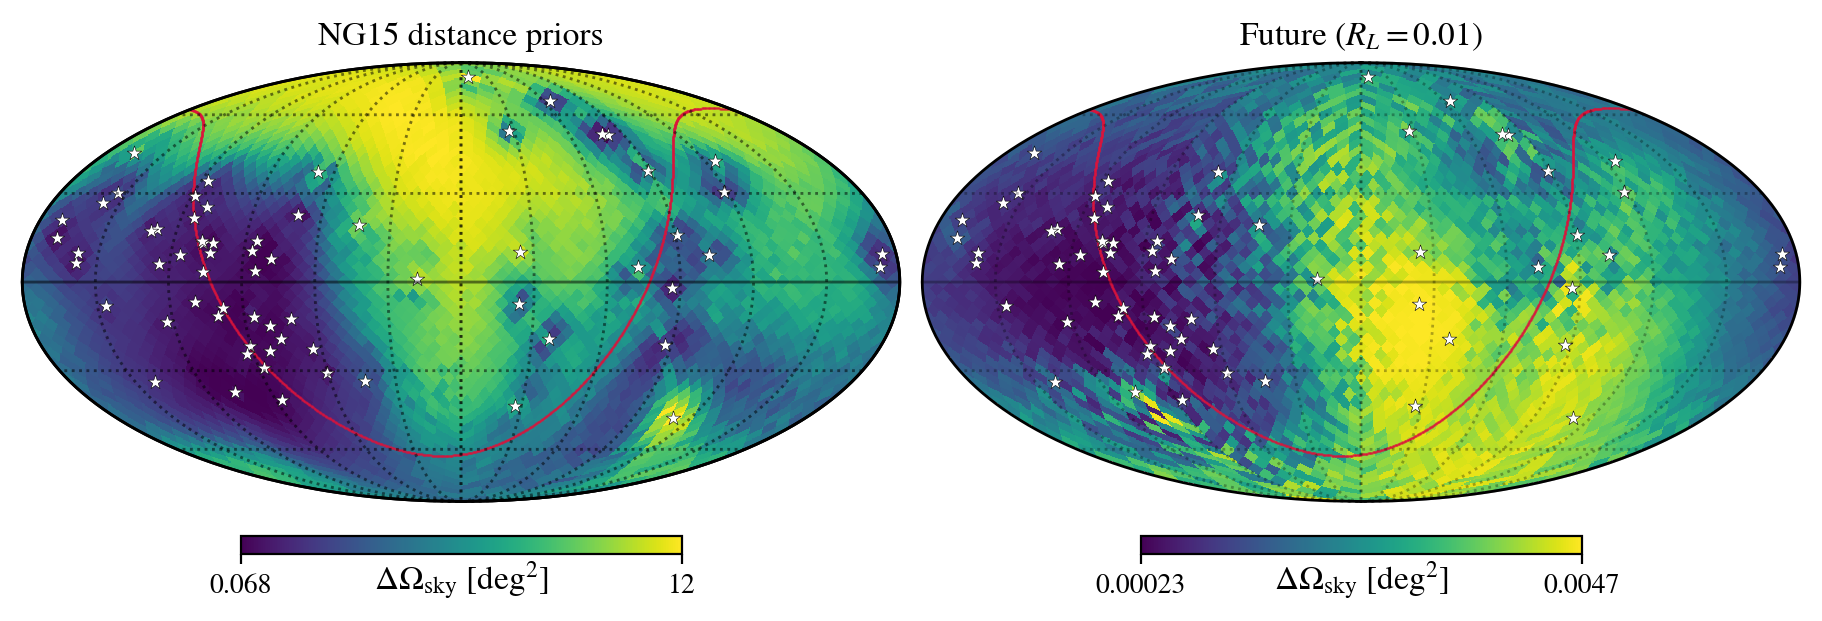

In [71]:
# Study R2b: figure (equatorial frame; Galactic plane dotted)
ra_psr_deg = np.degrees(np.asarray(batch.ra))
dec_psr_deg = np.degrees(np.asarray(batch.dec))
l_gp = np.linspace(0, 2 * np.pi, 1441)
ra_gp, dec_gp = ur.galactic_to_radec(l_gp, np.zeros_like(l_gp))

fig = plt.figure(figsize=(9, 3.4))
for i, (m, lab) in enumerate([(map_f1, r'NG15 distance priors'),
                              (map_f001, r'Future ($R_L=0.01$)')]):
    hp.mollview(m, sub=(1, 2, i + 1), title=lab, norm='hist', cmap='viridis',
                rot=(180.0, 0.0, 0.0), format='%.2g',
                unit=r'$\Delta\Omega_{\rm sky}$ [deg$^2$]', hold=False,
                margins=(0.005, 0.02, 0.005, 0.02))
    # nudge the unit label down 3 pt so the deg^2 clears the colorbar
    for txt in fig.axes[-1].texts:
        if 'Omega' in txt.get_text():
            txt.set_transform(txt.get_transform()
                              + matplotlib.transforms.ScaledTranslation(
                                  0.0, -3.0 / 72.0, fig.dpi_scale_trans))
    hp.projscatter(np.degrees(np.asarray(ra_gp)), np.degrees(np.asarray(dec_gp)),
                   lonlat=True, s=0.2, color='crimson', alpha=0.5, lw=0.5)
    hp.projscatter(ra_psr_deg, dec_psr_deg, lonlat=True, s=30, marker='*',
                   color='white', edgecolors='k', linewidths=0.2)
    hp.graticule(alpha=0.3)
plt.savefig('outputs_referee/ng15_skymap.pdf', bbox_inches='tight', dpi=400)
plt.show()

### Study R2b (continued) — phase-decoupled sky maps

The same all-sky study under the **phase-decoupled** model used by all current production CW pipelines (each pulsar-term phase a free, unconstrained nuisance parameter; $8 + 2\times67 = 142$ parameters). Same display convention and panel layout as the phase-linked maps above. Showing the same two panels ($R_L=1$ and $R_L=0.01$) makes the contrast with the phase-linked case pixel-by-pixel: a hundred-fold improvement in the distance priors leaves the decoupled map essentially unchanged, whereas the linked map improved by $\sim 10^3$.

In [ ]:
# Study R2b (continued): phase-decoupled all-sky maps
t_start = time.perf_counter()
map_D_f1 = ur.sky_map(batch, tref_ng, nside=16, chunk=32, frame='equatorial',
                      phase_free=True)
print(f"decoupled map R_L=1: {time.perf_counter()-t_start:.1f} s")
t_start = time.perf_counter()
map_D_f001 = ur.sky_map(ur.scale_pdist_sigma(batch, 0.01), tref_ng, nside=16,
                        chunk=32, frame='equatorial', phase_free=True)
print(f"decoupled map R_L=0.01: {time.perf_counter()-t_start:.1f} s")

np.savez('outputs_referee/referee_ng15_skymaps_decoupled.npz',
         map_D_f1=map_D_f1, map_D_f001=map_D_f001, nside=16, frame='equatorial')

for name, m in [('R_L=1   ', map_D_f1), ('R_L=0.01', map_D_f001)]:
    th_b, ph_b = hp.pix2ang(16, int(np.argmin(m)))
    ra_b, dec_b = np.degrees(ph_b), 90.0 - np.degrees(th_b)
    print(f"decoupled {name}: dOmega range [{m.min():.3e}, {m.max():.3e}] deg^2, "
          f"median {np.median(m):.3e}; best pixel at (RA, DEC) = "
          f"({ra_b:.0f}, {dec_b:+.0f}) deg")

# cross-checks against the phase-linked maps
print(f"\ndecoupled >= linked pixel-wise (R_L=1): "
      f"{100*np.mean(map_D_f1 >= map_f1):.1f}% of pixels")
print(f"max |map_D(R_L=0.01)/map_D(R_L=1) - 1| = "
      f"{np.max(np.abs(map_D_f001/map_D_f1 - 1)):.4f}")
print(f"median decoupled/linked ratio at R_L=1:    {np.median(map_D_f1/map_f1):8.1f}x")
print(f"median decoupled/linked ratio at R_L=0.01: {np.median(map_D_f001/map_f001):8.1f}x")

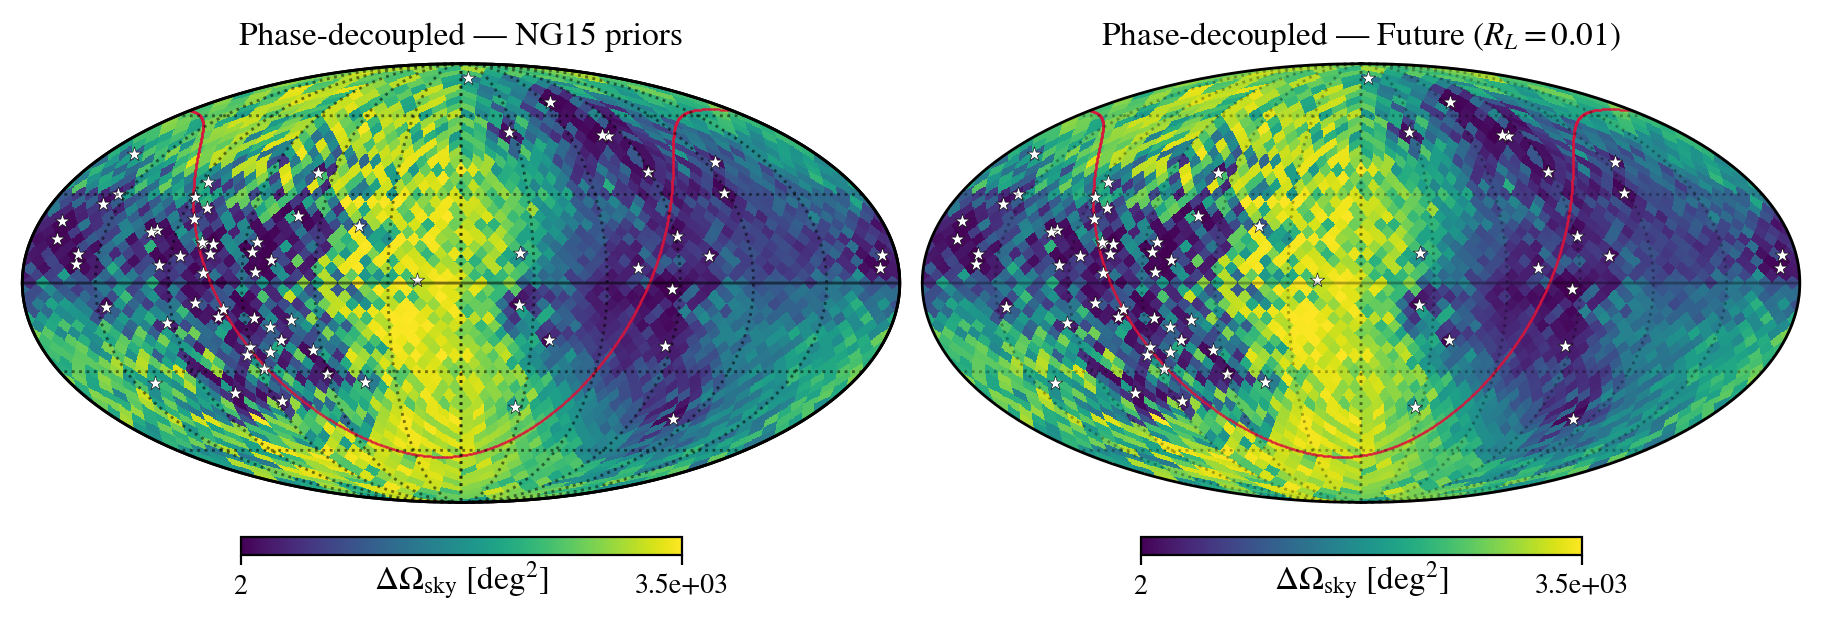

In [89]:
# Study R2b (continued): phase-decoupled figure (same convention as above)
fig = plt.figure(figsize=(9, 3.4))
for i, (m, lab) in enumerate([(map_D_f1, r'Phase-decoupled — NG15 priors'),
                              (map_D_f001, r'Phase-decoupled — Future ($R_L=0.01$)')]):
    hp.mollview(m, sub=(1, 2, i + 1), title=lab, norm='hist', cmap='viridis',
                rot=(180.0, 0.0, 0.0), format='%.2g',
                unit=r'$\Delta\Omega_{\rm sky}$ [deg$^2$]', hold=False,
                margins=(0.005, 0.02, 0.005, 0.02))
    # nudge the unit label down 3 pt so the deg^2 clears the colorbar
    for txt in fig.axes[-1].texts:
        if 'Omega' in txt.get_text():
            txt.set_transform(txt.get_transform()
                              + matplotlib.transforms.ScaledTranslation(
                                  0.0, -3.0 / 72.0, fig.dpi_scale_trans))
    hp.projscatter(np.degrees(np.asarray(ra_gp)), np.degrees(np.asarray(dec_gp)),
                   lonlat=True, s=0.2, color='crimson', alpha=0.5, lw=0.5)
    hp.projscatter(ra_psr_deg, dec_psr_deg, lonlat=True, s=30, marker='*',
                   color='white', edgecolors='k', linewidths=0.2)
    hp.graticule(alpha=0.3)
plt.savefig('outputs_referee/ng15_skymap_decoupled.pdf',
            bbox_inches='tight', dpi=400)
plt.show()

## Conclusions for the referee response

**Point 1 (overall configuration distance).** At fixed SNR, the phase-linked localization curve translates as $1/L_0^2$ in both regimes — $\Delta\Omega \propto (\sigma_L/L_0)^2$ when prior-limited, and $\propto (\omega L_0)^{-2}$ (interference-modulated) at the diffraction floor — while the saturation $\sigma_L$ is unchanged. Concretely, at $\xi = 50^\circ$, $\sigma_L = 0.05$ kpc: $\Delta\Omega = 14.9 \to 0.063$ deg$^2$ for $L_0 = 0.25 \to 4$ kpc. The phase-decoupled (production-pipeline) case is insensitive to $\sigma_L$ at every $L_0$; its level shifts $\mathcal{O}(1)$ with $L_0$ through Earth–pulsar-term frequency-separation effects.

**Points 2+3 (realistic NG15-like array).** With the actual NG15 CW-search distance priors and an SNR = 10 fiducial source, phase-linked localization spans $0.07$–$12.2$ deg$^2$ across the sky (median 2.8), with the best-localized region over the dense inner-Galaxy part of the array — best pixel at $({\rm RA},{\rm DEC}) \approx (259^\circ, +7^\circ)$, i.e. $(\ell, b) \approx (28^\circ, +25^\circ)$ — tracking the pulsar concentration (the best-localized decile of the sky has median $|b| = 19.5^\circ$ vs $30^\circ$ all-sky): in-plane sources localize $\sim 14\times$ better than a Galactic-pole source (0.6 vs 8.8 deg$^2$). With hundred-fold better distance priors the map improves by $\sim 10^3$ (median $2.5\times10^{-3}$ deg$^2$; best pixel $2.3\times10^{-4}$ deg$^2$ at $({\rm RA},{\rm DEC}) \approx (273^\circ, -5^\circ)$) and its morphology becomes interference-dominated; in the $R_L \to 0$ limit a pole source becomes fully competitive ($2.1\times10^{-4}$ deg$^2$), because the plane-concentrated array then sits at the near-optimal $\sim 60$–$90^\circ$ separations identified in the paper's Fig. 5. The phase-decoupled results are flat in $R_L$: at the three reference positions (350–2350 deg$^2$) to 0.3%, and pixel-by-pixel across the whole sky to at most 3.7% (companion decoupled maps: $\Delta\Omega = 2.0$–$3.5\times10^3$ deg$^2$, median 478; worse than phase-linked in every pixel, median ratio 165$\times$ at $R_L=1$ growing to $2.3\times10^5\times$ at $R_L=0.01$). Current production search pipelines would gain essentially nothing in localization from improved pulsar distances — the paper's central conclusion, re-verified on a realistic array.

All results are cross-checked against the audited production pipeline: the generalized ring machinery reproduces the paper's $L_0 = 1$ kpc values, the coordinate system is validated as equatorial J2000 (all 67 positions checked against the pulsars' name-encoded coordinates), the heterogeneous-array representation is verified against per-pulsar reference computations, and the scalings are anchored to the paper's analytic limits. Modeling assumptions: white noise at each pulsar's total post-fit rms (conservatively treating all residual power as noise), a uniform-cadence weight-preserving TOA grid, per-configuration SNR = 10 calibration, and the usual Fisher-matrix caveats (precision not accuracy, no timing-model fitting, priors as quadratic information).